# 02 · EDA y Rankings Financieros

## Objetivo del notebook

Este notebook realiza el **análisis exploratorio de datos (EDA)** sobre el dataset financiero limpio generado en la etapa de preparación.

El archivo principal de entrada es:

```text
01_datos_procesados/dataset_financiero_limpio.parquet
```

con respaldo en:

```text
01_datos_procesados/dataset_financiero_limpio.csv
```

La estructura esperada del dataset es:

```text
periodo | banco_estandarizado | indicador | valor | unidad | sentido
```

## Qué se realizará

1. Carga del dataset limpio.
2. Validación de estructura, tipos de datos y duplicados.
3. Revisión de bancos, periodos e indicadores.
4. Análisis descriptivo general.
5. Análisis de valores nulos.
6. Rankings financieros del último periodo.
7. Rankings históricos por periodo.
8. Comparación contra el promedio del sistema.
9. Detección inicial de outliers.
10. Análisis de evolución temporal.
11. Exportación de datasets derivados para el dashboard.

## Salidas esperadas

Los archivos derivados se guardarán en:

```text
01_datos_procesados/analisis/
```

Estos archivos serán insumo directo para el dashboard en Streamlit.

## 1. Importar librerías

Se importan librerías para análisis, manejo de rutas, validaciones y visualización básica.

In [51]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [52]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 150)
pd.set_option("display.width", 140)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Configurar rutas del proyecto

El notebook detecta automáticamente la raíz del proyecto buscando la carpeta `01_datos_procesados`.

Esto permite ejecutar el notebook desde:

- la raíz del proyecto;
- la carpeta `03_cuadernos`;
- otra subcarpeta interna del proyecto.

In [53]:
def encontrar_raiz_proyecto(nombre_carpeta_procesados: str = "01_datos_procesados") -> Path:
    """
    Busca la raíz del proyecto subiendo desde el directorio actual hasta encontrar
    la carpeta 01_datos_procesados.
    """
    actual = Path.cwd().resolve()
    candidatos = [actual] + list(actual.parents)

    for ruta in candidatos:
        if (ruta / nombre_carpeta_procesados).exists():
            return ruta

    raise FileNotFoundError(
        f"No se encontró la carpeta '{nombre_carpeta_procesados}' desde {actual}. "
        "Verifica que el notebook esté dentro del proyecto."
    )


RAIZ_PROYECTO = encontrar_raiz_proyecto()

CARPETA_PROCESADOS = RAIZ_PROYECTO / "01_datos_procesados"
CARPETA_ANALISIS = CARPETA_PROCESADOS / "analisis"

CARPETA_ANALISIS.mkdir(parents=True, exist_ok=True)

RUTA_DATASET_PARQUET = CARPETA_PROCESADOS / "dataset_financiero_limpio.parquet"
RUTA_DATASET_CSV = CARPETA_PROCESADOS / "dataset_financiero_limpio.csv"

RUTA_BANCOS = CARPETA_PROCESADOS / "dataset_bancos.csv"
RUTA_PERIODOS = CARPETA_PROCESADOS / "dataset_periodos.csv"

print("Raíz del proyecto:", RAIZ_PROYECTO)
print("Carpeta de datos procesados:", CARPETA_PROCESADOS)
print("Carpeta de análisis:", CARPETA_ANALISIS)

Raíz del proyecto: C:\Users\eddy.trejo\Documents\Seminario_Titulacion\GRUPO_02
Carpeta de datos procesados: C:\Users\eddy.trejo\Documents\Seminario_Titulacion\GRUPO_02\01_datos_procesados
Carpeta de análisis: C:\Users\eddy.trejo\Documents\Seminario_Titulacion\GRUPO_02\01_datos_procesados\analisis


## 3. Cargar dataset financiero limpio

Se prioriza la lectura en formato Parquet porque es más rápido y conserva mejor los tipos de datos.

Si el archivo Parquet no existe o falla, se usa el CSV como respaldo.

In [54]:
def cargar_dataset_financiero() -> pd.DataFrame:
    """
    Carga el dataset financiero limpio.
    Prioriza Parquet y usa CSV como respaldo.
    """
    if RUTA_DATASET_PARQUET.exists():
        try:
            print(f"Leyendo archivo Parquet: {RUTA_DATASET_PARQUET}")
            return pd.read_parquet(RUTA_DATASET_PARQUET)
        except Exception as e:
            print(f"No se pudo leer Parquet. Se intentará con CSV. Detalle: {repr(e)}")

    if RUTA_DATASET_CSV.exists():
        print(f"Leyendo archivo CSV: {RUTA_DATASET_CSV}")
        return pd.read_csv(RUTA_DATASET_CSV)

    raise FileNotFoundError(
        "No se encontró dataset_financiero_limpio.parquet ni dataset_financiero_limpio.csv "
        "en la carpeta 01_datos_procesados."
    )


df = cargar_dataset_financiero()

print("Dataset cargado correctamente.")
print("Filas:", len(df))
print("Columnas:", list(df.columns))

display(df.head(10))

Leyendo archivo Parquet: C:\Users\eddy.trejo\Documents\Seminario_Titulacion\GRUPO_02\01_datos_procesados\dataset_financiero_limpio.parquet
Dataset cargado correctamente.
Filas: 29730
Columnas: ['periodo', 'banco_estandarizado', 'indicador', 'valor', 'unidad', 'sentido']


,periodo,banco_estandarizado,indicador,valor,unidad,sentido
0,2009-01,AMAZONAS,activos_totales,111.57,millones_usd,mayor_es_tamano
1,2009-01,AMAZONAS,morosidad,4.55,porcentaje,menor_es_mejor
2,2009-01,AMAZONAS,pasivos_totales,100.08,millones_usd,informativo
3,2009-01,AMAZONAS,patrimonio,11.38,millones_usd,mayor_es_mejor
4,2009-01,AMAZONAS,roe,11.41,porcentaje,mayor_es_mejor
5,2009-01,AMAZONAS,solvencia_proxy,8.65,porcentaje,mayor_es_mejor
6,2009-01,AUSTRO,activos_totales,646.02,millones_usd,mayor_es_tamano
7,2009-01,AUSTRO,morosidad,6.10,porcentaje,menor_es_mejor
8,2009-01,AUSTRO,pasivos_totales,588.88,millones_usd,informativo
9,2009-01,AUSTRO,patrimonio,56.66,millones_usd,mayor_es_mejor


## 4. Validación inicial de estructura

La estructura mínima esperada es:

```text
periodo | banco_estandarizado | indicador | valor | unidad | sentido
```

Si falta alguna columna, se detiene el proceso porque el EDA depende de esa estructura.

In [55]:
COLUMNAS_ESPERADAS = [
    "periodo",
    "banco_estandarizado",
    "indicador",
    "valor",
    "unidad",
    "sentido"
]

columnas_faltantes = [col for col in COLUMNAS_ESPERADAS if col not in df.columns]

if columnas_faltantes:
    raise ValueError(f"Faltan columnas obligatorias en el dataset: {columnas_faltantes}")

# Se conserva únicamente la estructura limpia esperada para evitar columnas residuales.
df = df[COLUMNAS_ESPERADAS].copy()

# Limpieza básica defensiva de textos.
df["periodo"] = df["periodo"].astype(str).str.strip()
df["banco_estandarizado"] = df["banco_estandarizado"].astype(str).str.strip().str.upper()
df["indicador"] = df["indicador"].astype(str).str.strip().str.lower()
df["unidad"] = df["unidad"].astype(str).str.strip().str.lower()
df["sentido"] = df["sentido"].astype(str).str.strip().str.lower()

# Conversión numérica estricta de valor.
df["valor"] = pd.to_numeric(df["valor"], errors="coerce")

# Fecha mensual para ordenar correctamente la serie temporal.
df["periodo_dt"] = pd.to_datetime(df["periodo"] + "-01", errors="coerce")

print("Validación inicial completada.")
display(df.head(10))

Validación inicial completada.


,periodo,banco_estandarizado,indicador,valor,unidad,sentido,periodo_dt
0,2009-01,AMAZONAS,activos_totales,111.57,millones_usd,mayor_es_tamano,2009-01-01
1,2009-01,AMAZONAS,morosidad,4.55,porcentaje,menor_es_mejor,2009-01-01
2,2009-01,AMAZONAS,pasivos_totales,100.08,millones_usd,informativo,2009-01-01
3,2009-01,AMAZONAS,patrimonio,11.38,millones_usd,mayor_es_mejor,2009-01-01
4,2009-01,AMAZONAS,roe,11.41,porcentaje,mayor_es_mejor,2009-01-01
5,2009-01,AMAZONAS,solvencia_proxy,8.65,porcentaje,mayor_es_mejor,2009-01-01
6,2009-01,AUSTRO,activos_totales,646.02,millones_usd,mayor_es_tamano,2009-01-01
7,2009-01,AUSTRO,morosidad,6.10,porcentaje,menor_es_mejor,2009-01-01
8,2009-01,AUSTRO,pasivos_totales,588.88,millones_usd,informativo,2009-01-01
9,2009-01,AUSTRO,patrimonio,56.66,millones_usd,mayor_es_mejor,2009-01-01


## 5. Resumen general del dataset

En esta sección se valida el tamaño global del dataset:

- número de filas;
- bancos únicos;
- periodos únicos;
- indicadores disponibles;
- rango temporal.

In [56]:
resumen_general = {
    "filas": len(df),
    "bancos_unicos": df["banco_estandarizado"].nunique(),
    "periodos_unicos": df["periodo"].nunique(),
    "indicadores_unicos": df["indicador"].nunique(),
    "periodo_minimo": df["periodo"].min(),
    "periodo_maximo": df["periodo"].max(),
    "valores_nulos": int(df["valor"].isna().sum()),
    "porcentaje_nulos": round(df["valor"].isna().mean() * 100, 2)
}

display(pd.DataFrame([resumen_general]))

print("Indicadores disponibles:")
display(
    df["indicador"]
    .drop_duplicates()
    .sort_values()
    .to_frame(name="indicador")
    .reset_index(drop=True)
)

print("Bancos únicos encontrados:")
display(
    df["banco_estandarizado"]
    .drop_duplicates()
    .sort_values()
    .to_frame(name="banco_estandarizado")
    .reset_index(drop=True)
)

,filas,bancos_unicos,periodos_unicos,indicadores_unicos,periodo_minimo,periodo_maximo,valores_nulos,porcentaje_nulos
0,29730,32,205,6,2009-01,2026-03,234,0.79


Indicadores disponibles:


,indicador
0,activos_totales
1,morosidad
2,pasivos_totales
3,patrimonio
4,roe
5,solvencia_proxy


Bancos únicos encontrados:


,banco_estandarizado
0,AMAZONAS
1,ATLANTIDA
2,AUSTRO
3,BOLIVARIANO
4,CAPITAL
5,CITIBANK
6,COFIEC
7,COMERCIAL DE MANABI
8,COOPNACIONAL
9,D-MIRO


## 6. Validar indicadores esperados

Los indicadores esperados para el dashboard son:

- `activos_totales`
- `pasivos_totales`
- `patrimonio`
- `roe`
- `morosidad`
- `solvencia_proxy`

Si aparece un indicador adicional, no necesariamente es un error, pero conviene revisarlo.

In [65]:
INDICADORES_ESPERADOS = [
    "activos_totales",
    "pasivos_totales",
    "patrimonio",
    "roe",
    "morosidad",
    "solvencia_proxy"
]

indicadores_dataset = sorted(df["indicador"].dropna().unique())

indicadores_faltantes = sorted(set(INDICADORES_ESPERADOS) - set(indicadores_dataset))
indicadores_extra = sorted(set(indicadores_dataset) - set(INDICADORES_ESPERADOS))

print("Indicadores faltantes:", indicadores_faltantes)
print("Indicadores extra:", indicadores_extra)

display(
    df.groupby("indicador", dropna=False)
    .agg(
        filas=("valor", "size"),
        bancos=("banco_estandarizado", "nunique"),
        periodos=("periodo", "nunique"),
        nulos=("valor", lambda s: int(s.isna().sum())),
        porcentaje_nulos=("valor", lambda s: round(s.isna().mean() * 100, 2)),
        unidad=("unidad", lambda s: ", ".join(sorted(set(s.dropna())))),
        sentido=("sentido", lambda s: ", ".join(sorted(set(s.dropna())))),
    )
    .reset_index()
    .sort_values("indicador")
)

Indicadores faltantes: []
Indicadores extra: []


,indicador,filas,bancos,periodos,nulos,porcentaje_nulos,unidad,sentido
0,activos_totales,4963,32,205,49,0.99,millones_usd,mayor_es_tamano
1,morosidad,4963,32,205,5,0.10,porcentaje,menor_es_mejor
2,pasivos_totales,4963,32,205,49,0.99,millones_usd,informativo
3,patrimonio,4963,32,205,49,0.99,millones_usd,mayor_es_mejor
4,roe,4963,32,205,32,0.64,porcentaje,mayor_es_mejor
5,solvencia_proxy,4915,32,203,50,1.02,porcentaje,mayor_es_mejor


## 7. Validar duplicados por llave analítica

La llave analítica esperada es:

```text
periodo | banco_estandarizado | indicador
```

Debe existir una sola fila por banco, periodo e indicador.

Si hay duplicados, se revisan porque pueden distorsionar rankings, promedios y gráficos.

In [66]:
LLAVE_ANALITICA = ["periodo", "banco_estandarizado", "indicador"]

duplicados = df[df.duplicated(LLAVE_ANALITICA, keep=False)].copy()

print("Duplicados encontrados:", len(duplicados))

if not duplicados.empty:
    display(
        duplicados
        .sort_values(LLAVE_ANALITICA)
        .head(100)
    )
else:
    print("No existen duplicados por periodo, banco e indicador.")

Duplicados encontrados: 0
No existen duplicados por periodo, banco e indicador.


## 8. Control de cobertura por periodo e indicador

Este análisis muestra cuántos bancos tienen dato por cada indicador y periodo.

Sirve para identificar meses con menor cobertura o indicadores con problemas de disponibilidad.

In [59]:
cobertura_periodo_indicador = (
    df
    .groupby(["periodo", "indicador"], dropna=False)
    .agg(
        bancos_con_registro=("banco_estandarizado", "nunique"),
        filas=("valor", "size"),
        valores_no_nulos=("valor", lambda s: int(s.notna().sum())),
        valores_nulos=("valor", lambda s: int(s.isna().sum())),
        porcentaje_nulos=("valor", lambda s: round(s.isna().mean() * 100, 2))
    )
    .reset_index()
    .sort_values(["periodo", "indicador"])
)

display(cobertura_periodo_indicador.head(80))

,periodo,indicador,bancos_con_registro,filas,valores_no_nulos,valores_nulos,porcentaje_nulos
0,2009-01,activos_totales,25,25,25,0,0.0
1,2009-01,morosidad,25,25,25,0,0.0
2,2009-01,pasivos_totales,25,25,25,0,0.0
3,2009-01,patrimonio,25,25,25,0,0.0
4,2009-01,roe,25,25,25,0,0.0
5,2009-01,solvencia_proxy,25,25,25,0,0.0
6,2009-02,activos_totales,24,24,24,0,0.0
7,2009-02,morosidad,24,24,24,0,0.0
8,2009-02,pasivos_totales,24,24,24,0,0.0
9,2009-02,patrimonio,24,24,24,0,0.0


## 9. Análisis de valores nulos

Un valor `NaN` no significa cero.

En este proyecto:

- `0` significa que el banco declaró un valor igual a cero.
- `NaN` significa que el banco existía en ese periodo, pero el valor no fue declarado, no fue calculable o estaba vacío en el boletín.

In [60]:
nulos_por_indicador = (
    df
    .groupby("indicador", dropna=False)
    .agg(
        filas=("valor", "size"),
        nulos=("valor", lambda s: int(s.isna().sum())),
        porcentaje_nulos=("valor", lambda s: round(s.isna().mean() * 100, 2))
    )
    .reset_index()
    .sort_values("porcentaje_nulos", ascending=False)
)

display(nulos_por_indicador)

df_nulos = df[df["valor"].isna()].copy()

if df_nulos.empty:
    print("No existen valores nulos en la columna valor.")
else:
    print("Muestra de valores nulos:")
    display(df_nulos.head(100))

,indicador,filas,nulos,porcentaje_nulos
5,solvencia_proxy,4915,50,1.02
0,activos_totales,4963,49,0.99
3,patrimonio,4963,49,0.99
2,pasivos_totales,4963,49,0.99
4,roe,4963,32,0.64
1,morosidad,4963,5,0.10


Muestra de valores nulos:


,periodo,banco_estandarizado,indicador,valor,unidad,sentido,periodo_dt
7746,2013-03,TERRITORIAL,activos_totales,NaN,millones_usd,mayor_es_tamano,2013-03-01
7748,2013-03,TERRITORIAL,pasivos_totales,NaN,millones_usd,informativo,2013-03-01
7749,2013-03,TERRITORIAL,patrimonio,NaN,millones_usd,mayor_es_mejor,2013-03-01
7751,2013-03,TERRITORIAL,solvencia_proxy,NaN,porcentaje,mayor_es_mejor,2013-03-01
7902,2013-04,TERRITORIAL,activos_totales,NaN,millones_usd,mayor_es_tamano,2013-04-01
7904,2013-04,TERRITORIAL,pasivos_totales,NaN,millones_usd,informativo,2013-04-01
7905,2013-04,TERRITORIAL,patrimonio,NaN,millones_usd,mayor_es_mejor,2013-04-01
7907,2013-04,TERRITORIAL,solvencia_proxy,NaN,porcentaje,mayor_es_mejor,2013-04-01
7908,2013-04,UNIBANCO,activos_totales,NaN,millones_usd,mayor_es_tamano,2013-04-01
7910,2013-04,UNIBANCO,pasivos_totales,NaN,millones_usd,informativo,2013-04-01


## 10. Estadísticas descriptivas por indicador

Se calculan medidas generales para cada indicador:

- cantidad de registros;
- promedio;
- mediana;
- mínimo;
- máximo;
- desviación estándar;
- percentiles.

Estas medidas permiten entender el comportamiento del sistema financiero antes de construir rankings.

In [67]:
estadisticas_indicadores = (
    df
    .groupby("indicador", dropna=False)["valor"]
    .agg(
        registros="size",
        no_nulos="count",
        media="mean",
        mediana="median",
        minimo="min",
        p25=lambda s: s.quantile(0.25),
        p75=lambda s: s.quantile(0.75),
        maximo="max",
        desviacion_std="std"
    )
    .reset_index()
)

# Redondeo para lectura más cómoda.
for col in ["media", "mediana", "minimo", "p25", "p75", "maximo", "desviacion_std"]:
    estadisticas_indicadores[col] = estadisticas_indicadores[col].round(4)

display(estadisticas_indicadores)

,indicador,registros,no_nulos,media,mediana,minimo,p25,p75,maximo,desviacion_std
0,activos_totales,4963,4914,1661.5037,453.900,0.00,102.165,2117.4575,22343.92,2828.2823
1,morosidad,4963,4958,8.3891,4.060,0.00,2.510,6.9900,100.00,15.5472
2,pasivos_totales,4963,4914,1486.0209,408.605,0.00,85.375,1806.9575,20142.45,2543.4845
3,patrimonio,4963,4914,167.2969,46.695,0.00,14.540,191.1800,2211.09,276.3987
4,roe,4963,4931,11.3452,9.620,-99.33,4.690,14.6200,98.53,18.5058
5,solvencia_proxy,4915,4865,12.7233,9.640,3.61,7.980,14.7500,78.08,7.9320


## 11. Último periodo disponible

Se identifica automáticamente el último periodo del dataset.

Este periodo se usará para construir los rankings principales del dashboard.

In [68]:
ultimo_periodo_dt = df["periodo_dt"].max()

if pd.isna(ultimo_periodo_dt):
    raise ValueError("No se pudo calcular el último periodo. Revisa el formato de la columna periodo.")

ultimo_periodo = df.loc[df["periodo_dt"] == ultimo_periodo_dt, "periodo"].iloc[0]

print("Último periodo disponible:", ultimo_periodo)

df_ultimo_periodo = df[df["periodo"] == ultimo_periodo].copy()

display(
    df_ultimo_periodo
    .groupby("indicador")
    .agg(
        bancos=("banco_estandarizado", "nunique"),
        registros=("valor", "size"),
        valores_no_nulos=("valor", lambda s: int(s.notna().sum())),
        valores_nulos=("valor", lambda s: int(s.isna().sum()))
    )
    .reset_index()
)

Último periodo disponible: 2026-03


,indicador,bancos,registros,valores_no_nulos,valores_nulos
0,activos_totales,23,23,23,0
1,morosidad,23,23,23,0
2,pasivos_totales,23,23,23,0
3,patrimonio,23,23,23,0
4,roe,23,23,23,0
5,solvencia_proxy,23,23,23,0


## 12. Rankings del último periodo

Se generan rankings para cada indicador.

Regla de ordenamiento:

| Indicador | Criterio |
|---|---|
| `activos_totales` | Mayor es mejor para tamaño |
| `pasivos_totales` | Mayor a menor, porque representa escala financiera, no desempeño |
| `patrimonio` | Mayor a menor |
| `roe` | Mayor es mejor |
| `morosidad` | Menor es mejor |
| `solvencia_proxy` | Mayor es mejor |

La columna `ranking` empieza en 1.

In [70]:
def obtener_orden_ascendente(indicador: str, sentido: str = None) -> bool:
    """
    Define el sentido de ordenamiento para rankings.
    True significa ordenar de menor a mayor.
    False significa ordenar de mayor a menor.
    """
    indicador = str(indicador).lower()

    # En morosidad, menor valor significa mejor calidad de cartera.
    if indicador == "morosidad":
        return True

    # Para el resto de indicadores, se ordena de mayor a menor.
    return False


def crear_ranking_por_periodo(df_base: pd.DataFrame) -> pd.DataFrame:
    """
    Crea rankings por periodo e indicador.
    Ignora valores nulos para evitar rankings sobre datos no declarados.
    """
    partes = []

    for (periodo, indicador), grupo in df_base.groupby(["periodo", "indicador"], dropna=False):
        grupo = grupo.copy()
        grupo = grupo[grupo["valor"].notna()].copy()

        if grupo.empty:
            continue

        sentido = grupo["sentido"].dropna().iloc[0] if grupo["sentido"].notna().any() else None
        ascendente = obtener_orden_ascendente(indicador, sentido)

        grupo = grupo.sort_values("valor", ascending=ascendente)
        grupo["ranking"] = range(1, len(grupo) + 1)

        partes.append(grupo)

    if not partes:
        return pd.DataFrame()

    return pd.concat(partes, ignore_index=True)


df_ranking_historico = crear_ranking_por_periodo(df)

df_ranking_ultimo_periodo = (
    df_ranking_historico[df_ranking_historico["periodo"] == ultimo_periodo]
    .copy()
    .sort_values(["indicador", "ranking"])
)

display(df_ranking_ultimo_periodo.head(300))

,periodo,banco_estandarizado,indicador,valor,unidad,sentido,periodo_dt,ranking
29358,2026-03,PICHINCHA,activos_totales,22343.92,millones_usd,mayor_es_tamano,2026-03-01,1
29359,2026-03,GUAYAQUIL,activos_totales,10455.87,millones_usd,mayor_es_tamano,2026-03-01,2
29360,2026-03,PACIFICO,activos_totales,10241.40,millones_usd,mayor_es_tamano,2026-03-01,3
29361,2026-03,PRODUBANCO,activos_totales,9198.75,millones_usd,mayor_es_tamano,2026-03-01,4
29362,2026-03,BOLIVARIANO,activos_totales,6282.75,millones_usd,mayor_es_tamano,2026-03-01,5
29363,2026-03,INTERNACIONAL,activos_totales,6208.41,millones_usd,mayor_es_tamano,2026-03-01,6
29364,2026-03,AUSTRO,activos_totales,3528.07,millones_usd,mayor_es_tamano,2026-03-01,7
29365,2026-03,DINERS,activos_totales,3323.48,millones_usd,mayor_es_tamano,2026-03-01,8
29366,2026-03,GENERAL RUMIÑAHUI,activos_totales,1436.51,millones_usd,mayor_es_tamano,2026-03-01,9
29367,2026-03,MACHALA,activos_totales,1276.50,millones_usd,mayor_es_tamano,2026-03-01,10


## 13. Top 10 por indicador en el último periodo

Esta sección imprime una vista ejecutiva de los 10 primeros bancos por indicador.

In [71]:
for indicador in INDICADORES_ESPERADOS:
    ranking_ind = df_ranking_ultimo_periodo[
        df_ranking_ultimo_periodo["indicador"] == indicador
    ].copy()

    if ranking_ind.empty:
        print(f"\nIndicador sin ranking: {indicador}")
        continue

    print(f"\nTop 10 - {indicador} - periodo {ultimo_periodo}")
    display(
        ranking_ind[
            ["ranking", "banco_estandarizado", "indicador", "valor", "unidad", "sentido"]
        ].head(10)
    )


Top 10 - activos_totales - periodo 2026-03


,ranking,banco_estandarizado,indicador,valor,unidad,sentido
29358,1,PICHINCHA,activos_totales,22343.92,millones_usd,mayor_es_tamano
29359,2,GUAYAQUIL,activos_totales,10455.87,millones_usd,mayor_es_tamano
29360,3,PACIFICO,activos_totales,10241.40,millones_usd,mayor_es_tamano
29361,4,PRODUBANCO,activos_totales,9198.75,millones_usd,mayor_es_tamano
29362,5,BOLIVARIANO,activos_totales,6282.75,millones_usd,mayor_es_tamano
29363,6,INTERNACIONAL,activos_totales,6208.41,millones_usd,mayor_es_tamano
29364,7,AUSTRO,activos_totales,3528.07,millones_usd,mayor_es_tamano
29365,8,DINERS,activos_totales,3323.48,millones_usd,mayor_es_tamano
29366,9,GENERAL RUMIÑAHUI,activos_totales,1436.51,millones_usd,mayor_es_tamano
29367,10,MACHALA,activos_totales,1276.50,millones_usd,mayor_es_tamano



Top 10 - pasivos_totales - periodo 2026-03


,ranking,banco_estandarizado,indicador,valor,unidad,sentido
29404,1,PICHINCHA,pasivos_totales,20142.45,millones_usd,informativo
29405,2,GUAYAQUIL,pasivos_totales,9564.68,millones_usd,informativo
29406,3,PACIFICO,pasivos_totales,9063.59,millones_usd,informativo
29407,4,PRODUBANCO,pasivos_totales,8469.82,millones_usd,informativo
29408,5,BOLIVARIANO,pasivos_totales,5676.80,millones_usd,informativo
29409,6,INTERNACIONAL,pasivos_totales,5649.99,millones_usd,informativo
29410,7,AUSTRO,pasivos_totales,3232.74,millones_usd,informativo
29411,8,DINERS,pasivos_totales,2733.81,millones_usd,informativo
29412,9,GENERAL RUMIÑAHUI,pasivos_totales,1297.41,millones_usd,informativo
29413,10,MACHALA,pasivos_totales,1183.06,millones_usd,informativo



Top 10 - patrimonio - periodo 2026-03


...

,ranking,banco_estandarizado,indicador,valor,unidad,sentido
29450,1,COMERCIAL DE MANABI,roe,98.34,porcentaje,mayor_es_mejor
29451,2,AMAZONAS,roe,22.21,porcentaje,mayor_es_mejor
29452,3,VISIONFUND ECUADOR,roe,22.12,porcentaje,mayor_es_mejor
29453,4,PACIFICO,roe,21.51,porcentaje,mayor_es_mejor
29454,5,CITIBANK,roe,18.65,porcentaje,mayor_es_mejor
29455,6,GUAYAQUIL,roe,17.60,porcentaje,mayor_es_mejor
29456,7,GENERAL RUMIÑAHUI,roe,14.28,porcentaje,mayor_es_mejor
29457,8,PRODUBANCO,roe,14.25,porcentaje,mayor_es_mejor
29458,9,LOJA,roe,13.86,porcentaje,mayor_es_mejor
29459,10,DELBANK,roe,13.55,porcentaje,mayor_es_mejor



Top 10 - morosidad - periodo 2026-03


,ranking,banco_estandarizado,indicador,valor,unidad,sentido
29381,1,CITIBANK,morosidad,0.00,porcentaje,menor_es_mejor
29382,2,BOLIVARIANO,morosidad,1.62,porcentaje,menor_es_mejor
29383,3,INTERNACIONAL,morosidad,1.66,porcentaje,menor_es_mejor
29384,4,GUAYAQUIL,morosidad,2.30,porcentaje,menor_es_mejor
29385,5,PACIFICO,morosidad,2.45,porcentaje,menor_es_mejor
29386,6,MACHALA,morosidad,2.51,porcentaje,menor_es_mejor
29387,7,COMERCIAL DE MANABI,morosidad,2.56,porcentaje,menor_es_mejor
29388,8,ATLANTIDA,morosidad,2.63,porcentaje,menor_es_mejor
29389,9,DELBANK,morosidad,2.85,porcentaje,menor_es_mejor
29390,10,PRODUBANCO,morosidad,2.89,porcentaje,menor_es_mejor



Top 10 - solvencia_proxy - periodo 2026-03


,ranking,banco_estandarizado,indicador,valor,unidad,sentido
29473,1,DELBANK,solvencia_proxy,28.52,porcentaje,mayor_es_mejor
29474,2,LITORAL,solvencia_proxy,23.60,porcentaje,mayor_es_mejor
29475,3,SOLIDARIO,solvencia_proxy,17.99,porcentaje,mayor_es_mejor
29476,4,DINERS,solvencia_proxy,16.08,porcentaje,mayor_es_mejor
29477,5,VISIONFUND ECUADOR,solvencia_proxy,13.52,porcentaje,mayor_es_mejor
29478,6,COOPNACIONAL,solvencia_proxy,13.03,porcentaje,mayor_es_mejor
29479,7,CITIBANK,solvencia_proxy,11.95,porcentaje,mayor_es_mejor
29480,8,COMERCIAL DE MANABI,solvencia_proxy,11.02,porcentaje,mayor_es_mejor
29481,9,CAPITAL,solvencia_proxy,10.24,porcentaje,mayor_es_mejor
29482,10,PACIFICO,solvencia_proxy,10.22,porcentaje,mayor_es_mejor


## 14. Comparación contra promedio del sistema

Para cada periodo e indicador se calcula el promedio del sistema.

Luego se compara cada banco contra ese promedio:

```text
diferencia_vs_promedio = valor_banco - promedio_sistema
```

También se calcula una diferencia porcentual respecto al promedio.

Esto ayuda a responder si un banco está por encima o por debajo del sistema.

In [72]:
promedio_sistema = (
    df
    .groupby(["periodo", "indicador"], dropna=False)
    .agg(
        promedio_sistema=("valor", "mean"),
        mediana_sistema=("valor", "median"),
        bancos_con_dato=("valor", "count")
    )
    .reset_index()
)

df_vs_sistema = df.merge(
    promedio_sistema,
    on=["periodo", "indicador"],
    how="left"
)

df_vs_sistema["diferencia_vs_promedio"] = (
    df_vs_sistema["valor"] - df_vs_sistema["promedio_sistema"]
)

df_vs_sistema["diferencia_pct_vs_promedio"] = np.where(
    df_vs_sistema["promedio_sistema"].notna() & (df_vs_sistema["promedio_sistema"] != 0),
    (df_vs_sistema["diferencia_vs_promedio"] / df_vs_sistema["promedio_sistema"]) * 100,
    np.nan
)

display(df_vs_sistema.head(20))

,periodo,banco_estandarizado,indicador,valor,unidad,sentido,periodo_dt,promedio_sistema,mediana_sistema,bancos_con_dato,diferencia_vs_promedio,diferencia_pct_vs_promedio
0,2009-01,AMAZONAS,activos_totales,111.57,millones_usd,mayor_es_tamano,2009-01-01,643.2348,288.57,25,-531.6648,-82.654856
1,2009-01,AMAZONAS,morosidad,4.55,porcentaje,menor_es_mejor,2009-01-01,5.5636,3.63,25,-1.0136,-18.218420
2,2009-01,AMAZONAS,pasivos_totales,100.08,millones_usd,informativo,2009-01-01,574.6976,252.10,25,-474.6176,-82.585624
3,2009-01,AMAZONAS,patrimonio,11.38,millones_usd,mayor_es_mejor,2009-01-01,67.8408,28.96,25,-56.4608,-83.225434
4,2009-01,AMAZONAS,roe,11.41,porcentaje,mayor_es_mejor,2009-01-01,14.4696,11.64,25,-3.0596,-21.145021
5,2009-01,AMAZONAS,solvencia_proxy,8.65,porcentaje,mayor_es_mejor,2009-01-01,14.4480,9.44,25,-5.7980,-40.130122
6,2009-01,AUSTRO,activos_totales,646.02,millones_usd,mayor_es_tamano,2009-01-01,643.2348,288.57,25,2.7852,0.432999
7,2009-01,AUSTRO,morosidad,6.10,porcentaje,menor_es_mejor,2009-01-01,5.5636,3.63,25,0.5364,9.641239
8,2009-01,AUSTRO,pasivos_totales,588.88,millones_usd,informativo,2009-01-01,574.6976,252.10,25,14.1824,2.467802
9,2009-01,AUSTRO,patrimonio,56.66,millones_usd,mayor_es_mejor,2009-01-01,67.8408,28.96,25,-11.1808,-16.480938


## 15. Ranking del último periodo con comparación contra sistema

Se crea una tabla enriquecida del último periodo con:

- ranking;
- valor del banco;
- promedio del sistema;
- diferencia absoluta;
- diferencia porcentual.

In [73]:
df_ranking_ultimo_vs_sistema = df_ranking_ultimo_periodo.merge(
    promedio_sistema,
    on=["periodo", "indicador"],
    how="left"
)

df_ranking_ultimo_vs_sistema["diferencia_vs_promedio"] = (
    df_ranking_ultimo_vs_sistema["valor"] - df_ranking_ultimo_vs_sistema["promedio_sistema"]
)

df_ranking_ultimo_vs_sistema["diferencia_pct_vs_promedio"] = np.where(
    df_ranking_ultimo_vs_sistema["promedio_sistema"].notna()
    & (df_ranking_ultimo_vs_sistema["promedio_sistema"] != 0),
    (df_ranking_ultimo_vs_sistema["diferencia_vs_promedio"] / df_ranking_ultimo_vs_sistema["promedio_sistema"]) * 100,
    np.nan
)

display(
    df_ranking_ultimo_vs_sistema[
        [
            "periodo",
            "ranking",
            "banco_estandarizado",
            "indicador",
            "valor",
            "promedio_sistema",
            "diferencia_vs_promedio",
            "diferencia_pct_vs_promedio",
            "unidad",
            "sentido"
        ]
    ].head(100)
)

,periodo,ranking,banco_estandarizado,indicador,valor,promedio_sistema,diferencia_vs_promedio,diferencia_pct_vs_promedio,unidad,sentido
0,2026-03,1,PICHINCHA,activos_totales,22343.92,3450.851739,18893.068261,547.490002,millones_usd,mayor_es_tamano
1,2026-03,2,GUAYAQUIL,activos_totales,10455.87,3450.851739,7005.018261,202.993892,millones_usd,mayor_es_tamano
2,2026-03,3,PACIFICO,activos_totales,10241.40,3450.851739,6790.548261,196.778905,millones_usd,mayor_es_tamano
3,2026-03,4,PRODUBANCO,activos_totales,9198.75,3450.851739,5747.898261,166.564625,millones_usd,mayor_es_tamano
4,2026-03,5,BOLIVARIANO,activos_totales,6282.75,3450.851739,2831.898261,82.063748,millones_usd,mayor_es_tamano
5,2026-03,6,INTERNACIONAL,activos_totales,6208.41,3450.851739,2757.558261,79.909497,millones_usd,mayor_es_tamano
6,2026-03,7,AUSTRO,activos_totales,3528.07,3450.851739,77.218261,2.237658,millones_usd,mayor_es_tamano
7,2026-03,8,DINERS,activos_totales,3323.48,3450.851739,-127.371739,-3.691023,millones_usd,mayor_es_tamano
8,2026-03,9,GENERAL RUMIÑAHUI,activos_totales,1436.51,3450.851739,-2014.341739,-58.372306,millones_usd,mayor_es_tamano
9,2026-03,10,MACHALA,activos_totales,1276.50,3450.851739,-2174.351739,-63.009132,millones_usd,mayor_es_tamano


## 16. Detección inicial de outliers

Se detectan posibles valores atípicos usando dos criterios:

1. **Z-score por indicador**: mide cuántas desviaciones estándar se aleja un valor del promedio.
2. **Rango intercuartílico (IQR)**: identifica valores por debajo o por encima de límites robustos.

Un outlier financiero no debe eliminarse automáticamente. Primero debe revisarse porque puede representar:

- una institución especializada;
- un cambio regulatorio;
- un error de origen;
- un evento financiero relevante.

In [75]:
# Se trabaja únicamente con valores no nulos.
# Los valores NaN representan datos no declarados o no calculables,
# por tanto no deben entrar al cálculo estadístico de outliers.
df_outliers = df[df["valor"].notna()].copy()

# ------------------------------------------------------------
# Validación mínima
# ------------------------------------------------------------
# Antes de calcular outliers, verificamos que existan las columnas necesarias.
columnas_requeridas_outliers = [
    "periodo",
    "banco_estandarizado",
    "indicador",
    "valor"
]

columnas_faltantes_outliers = [
    col for col in columnas_requeridas_outliers
    if col not in df_outliers.columns
]

if columnas_faltantes_outliers:
    raise ValueError(
        f"Faltan columnas necesarias para calcular outliers: {columnas_faltantes_outliers}"
    )


# ------------------------------------------------------------
# Cálculo por grupo: periodo + indicador
# ------------------------------------------------------------
# La comparación debe hacerse dentro de cada periodo e indicador.
# Ejemplo:
# - ROE de bancos en 2025-02 contra otros ROE de 2025-02.
# - Morosidad de bancos en 2024-06 contra otras morosidades de 2024-06.
grupo_outliers = df_outliers.groupby(["periodo", "indicador"])["valor"]

# Cantidad de bancos con dato dentro de cada periodo e indicador.
df_outliers["observaciones_grupo"] = grupo_outliers.transform("count")

# Media y desviación estándar del grupo.
df_outliers["media_grupo"] = grupo_outliers.transform("mean")
df_outliers["desviacion_grupo"] = grupo_outliers.transform("std")

# Z-score:
# mide cuántas desviaciones estándar se aleja cada banco del promedio del grupo.
df_outliers["z_score"] = np.where(
    df_outliers["desviacion_grupo"].notna()
    & (df_outliers["desviacion_grupo"] != 0),
    (df_outliers["valor"] - df_outliers["media_grupo"]) / df_outliers["desviacion_grupo"],
    np.nan
)


# ------------------------------------------------------------
# Cálculo de límites por IQR
# ------------------------------------------------------------
# Q1: percentil 25.
# Q3: percentil 75.
# IQR: rango intercuartílico = Q3 - Q1.
df_outliers["q1"] = grupo_outliers.transform(lambda s: s.quantile(0.25))
df_outliers["q3"] = grupo_outliers.transform(lambda s: s.quantile(0.75))

df_outliers["iqr"] = df_outliers["q3"] - df_outliers["q1"]

# Límites clásicos para detectar valores atípicos.
df_outliers["limite_inferior_iqr"] = df_outliers["q1"] - 1.5 * df_outliers["iqr"]
df_outliers["limite_superior_iqr"] = df_outliers["q3"] + 1.5 * df_outliers["iqr"]


# ------------------------------------------------------------
# Banderas de outlier
# ------------------------------------------------------------
# Criterio 1: Z-score absoluto mayor o igual a 3.
df_outliers["outlier_z_score"] = df_outliers["z_score"].abs() >= 3

# Criterio 2: valor fuera de los límites IQR.
df_outliers["outlier_iqr"] = (
    (df_outliers["valor"] < df_outliers["limite_inferior_iqr"])
    | (df_outliers["valor"] > df_outliers["limite_superior_iqr"])
)

# Outlier final:
# será True si cumple cualquiera de los dos criterios.
df_outliers["es_outlier"] = (
    df_outliers["outlier_z_score"]
    | df_outliers["outlier_iqr"]
)


# ------------------------------------------------------------
# Dataset de outliers detectados
# ------------------------------------------------------------
df_outliers_detectados = df_outliers[df_outliers["es_outlier"]].copy()

print("Outliers detectados:", len(df_outliers_detectados))


# ------------------------------------------------------------
# Visualización segura
# ------------------------------------------------------------
# Se muestran únicamente columnas que existan en el DataFrame.
columnas_mostrar_outliers = [
    "periodo",
    "banco_estandarizado",
    "indicador",
    "valor",
    "observaciones_grupo",
    "z_score",
    "limite_inferior_iqr",
    "limite_superior_iqr",
    "outlier_z_score",
    "outlier_iqr"
]

columnas_mostrar_outliers = [
    col for col in columnas_mostrar_outliers
    if col in df_outliers_detectados.columns
]

if df_outliers_detectados.empty:
    print("No se detectaron outliers con los criterios definidos.")
else:
    display(
        df_outliers_detectados[columnas_mostrar_outliers]
        .sort_values(["periodo", "indicador", "banco_estandarizado"])
        .head(100)
    )


# ------------------------------------------------------------
# Resumen de outliers por indicador
# ------------------------------------------------------------
if not df_outliers_detectados.empty:
    resumen_outliers = (
        df_outliers_detectados
        .groupby("indicador", dropna=False)
        .agg(
            outliers=("valor", "size"),
            bancos_afectados=("banco_estandarizado", "nunique"),
            periodos_afectados=("periodo", "nunique")
        )
        .reset_index()
        .sort_values("outliers", ascending=False)
    )

    display(resumen_outliers)

Outliers detectados: 2679


,periodo,banco_estandarizado,indicador,valor,observaciones_grupo,z_score,limite_inferior_iqr,limite_superior_iqr,outlier_z_score,outlier_iqr
60,2009-01,GUAYAQUIL,activos_totales,2180.19,25,1.561852,-804.53000,1516.35000,False,True
102,2009-01,PACIFICO,activos_totales,1734.25,25,1.108688,-804.53000,1516.35000,False,True
108,2009-01,PICHINCHA,activos_totales,4353.79,25,3.770662,-804.53000,1516.35000,True,True
120,2009-01,PRODUBANCO,activos_totales,1585.62,25,0.957651,-804.53000,1516.35000,False,True
31,2009-01,COFIEC,morosidad,23.99,25,3.380456,-3.20000,11.68000,True,True
133,2009-01,SUDAMERICANO,morosidad,18.60,25,2.391622,-3.20000,11.68000,False,True
62,2009-01,GUAYAQUIL,pasivos_totales,2002.92,25,1.620868,-748.17000,1391.11000,False,True
104,2009-01,PACIFICO,pasivos_totales,1462.20,25,1.007213,-748.17000,1391.11000,False,True
110,2009-01,PICHINCHA,pasivos_totales,3888.59,25,3.760886,-748.17000,1391.11000,True,True
122,2009-01,PRODUBANCO,pasivos_totales,1431.44,25,0.972304,-748.17000,1391.11000,False,True


,indicador,outliers,bancos_afectados,periodos_afectados
4,roe,647,24,200
1,morosidad,520,19,199
3,patrimonio,418,4,205
5,solvencia_proxy,376,10,177
0,activos_totales,360,4,205
2,pasivos_totales,358,4,205


## 17. Evolución temporal por indicador

Se genera una vista agregada por periodo e indicador.

Esto ayuda a observar la evolución general del sistema financiero a lo largo del tiempo.

In [76]:
evolucion_sistema = (
    df
    .groupby(["periodo", "periodo_dt", "indicador"], dropna=False)
    .agg(
        promedio=("valor", "mean"),
        mediana=("valor", "median"),
        minimo=("valor", "min"),
        maximo=("valor", "max"),
        bancos_con_dato=("valor", "count")
    )
    .reset_index()
    .sort_values(["indicador", "periodo_dt"])
)

display(evolucion_sistema.head(50))

,periodo,periodo_dt,indicador,promedio,mediana,minimo,maximo,bancos_con_dato
0,2009-01,2009-01-01,activos_totales,643.234800,288.570,8.31,4353.79,25
6,2009-02,2009-02-01,activos_totales,651.250833,270.625,8.33,4326.13,24
12,2009-03,2009-03-01,activos_totales,634.892400,288.540,8.85,4288.87,25
18,2009-04,2009-04-01,activos_totales,641.791600,267.060,8.48,4427.24,25
24,2009-05,2009-05-01,activos_totales,644.408400,280.770,8.47,4450.86,25
30,2009-06,2009-06-01,activos_totales,639.936000,295.780,8.54,4339.20,25
36,2009-07,2009-07-01,activos_totales,646.425200,287.860,8.52,4434.20,25
42,2009-08,2009-08-01,activos_totales,660.585600,291.220,8.55,4453.47,25
48,2009-09,2009-09-01,activos_totales,654.759200,291.420,8.64,4469.44,25
54,2009-10,2009-10-01,activos_totales,659.272000,280.640,8.06,4520.85,25


## 18. Gráficos exploratorios rápidos

Estos gráficos permiten validar visualmente tendencias generales.

No reemplazan el dashboard; solo sirven como exploración inicial dentro del notebook.

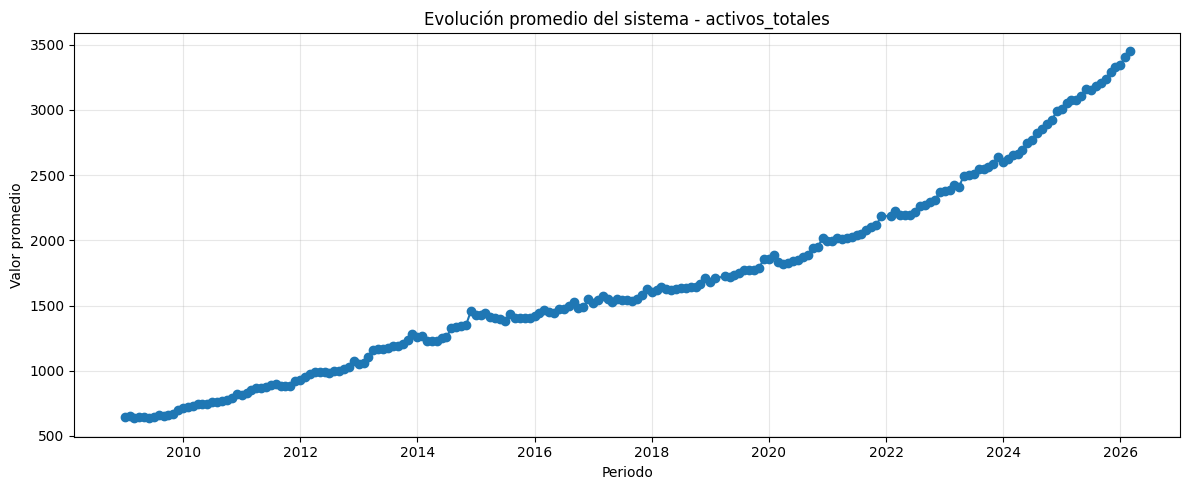

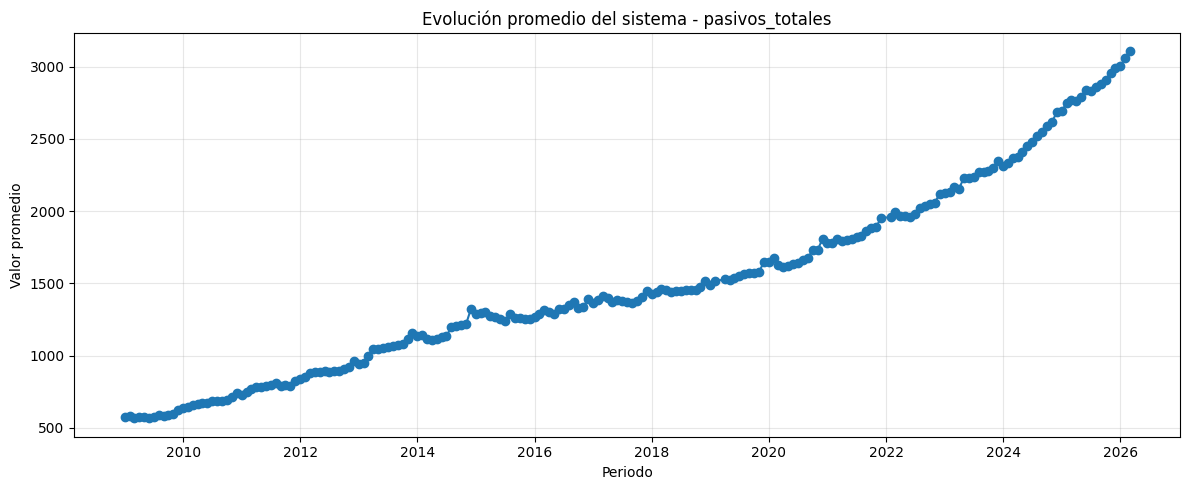

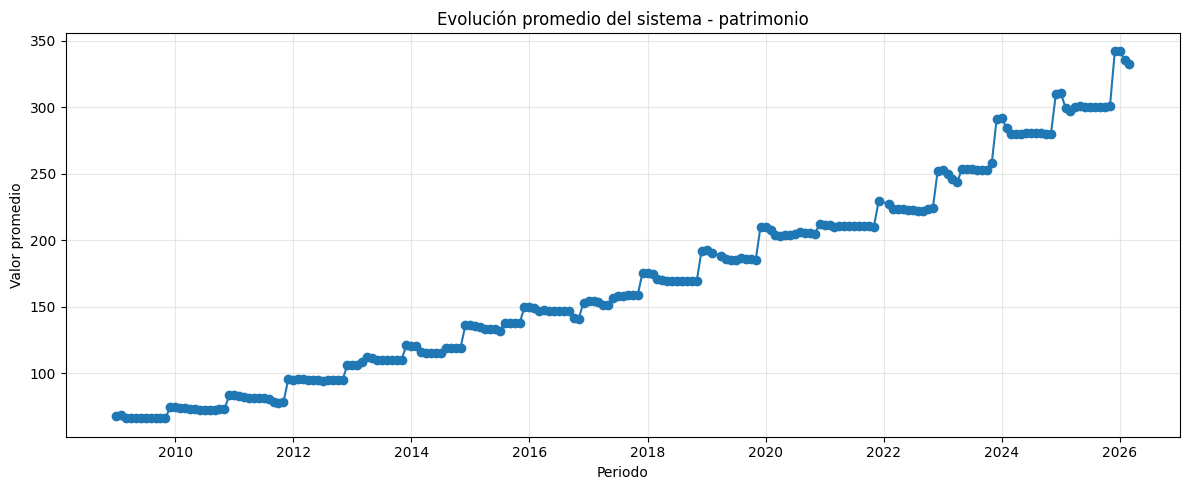

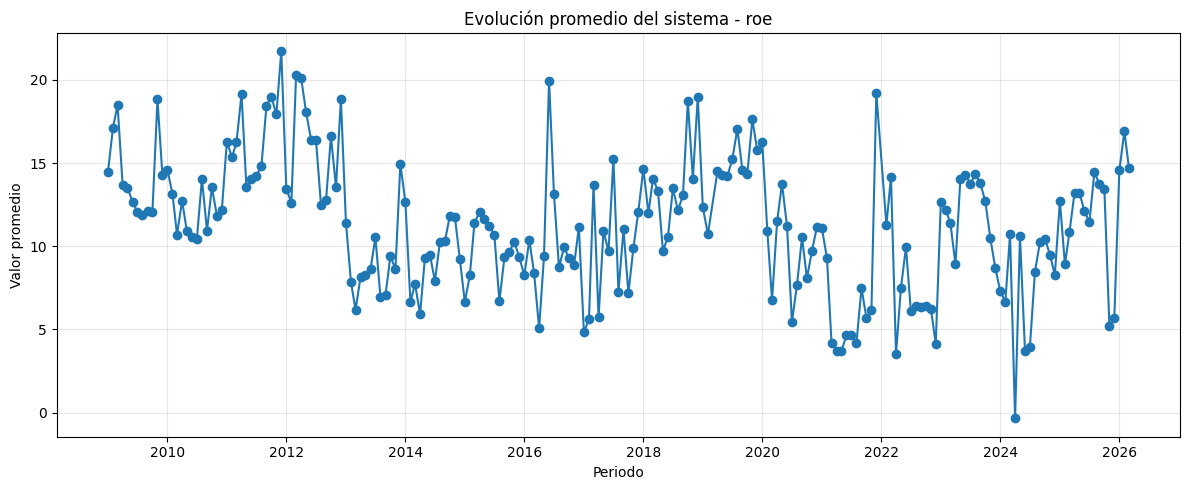

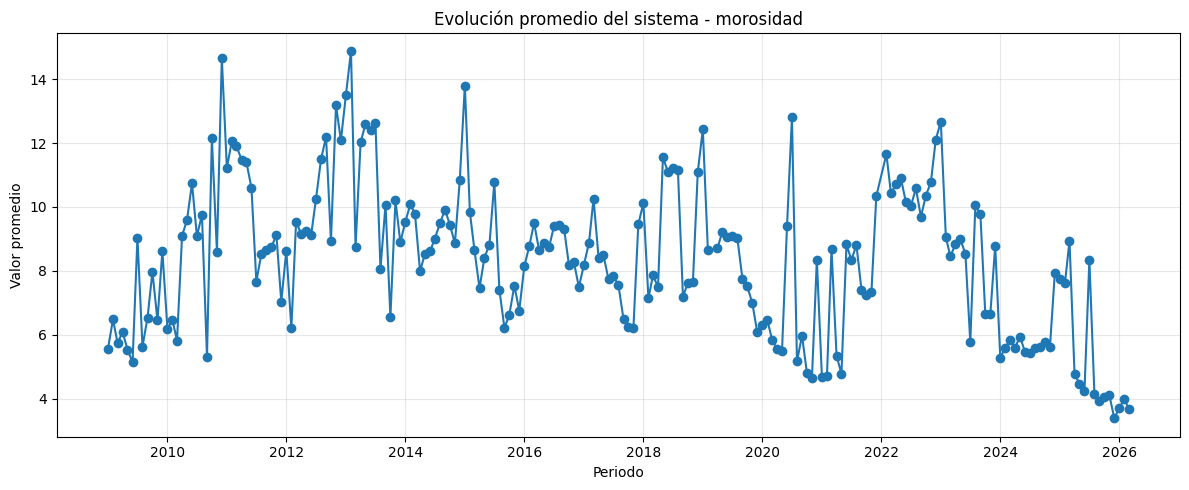

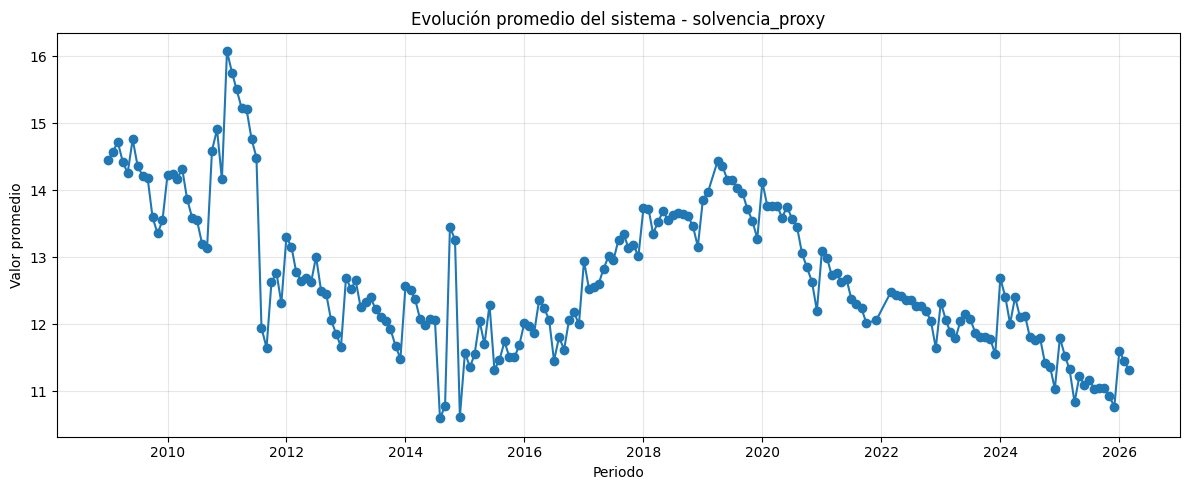

In [77]:
for indicador in INDICADORES_ESPERADOS:
    data_plot = evolucion_sistema[evolucion_sistema["indicador"] == indicador].copy()

    if data_plot.empty:
        continue

    plt.figure(figsize=(12, 5))
    plt.plot(data_plot["periodo_dt"], data_plot["promedio"], marker="o")
    plt.title(f"Evolución promedio del sistema - {indicador}")
    plt.xlabel("Periodo")
    plt.ylabel("Valor promedio")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 19. Matriz banco-indicador del último periodo

Esta matriz es útil para una vista rápida tipo tablero.

Cada fila representa un banco y cada columna un indicador.

In [78]:
matriz_ultimo_periodo = (
    df_ultimo_periodo
    .pivot_table(
        index="banco_estandarizado",
        columns="indicador",
        values="valor",
        aggfunc="first"
    )
    .reset_index()
)

# Orden sugerido de columnas.
columnas_matriz = ["banco_estandarizado"] + [
    indicador for indicador in INDICADORES_ESPERADOS
    if indicador in matriz_ultimo_periodo.columns
]

matriz_ultimo_periodo = matriz_ultimo_periodo[columnas_matriz]

display(matriz_ultimo_periodo.head(50))

indicador,banco_estandarizado,activos_totales,pasivos_totales,patrimonio,roe,morosidad,solvencia_proxy
0,AMAZONAS,458.55,413.84,44.68,22.21,3.11,7.92
1,ATLANTIDA,149.50,137.73,11.72,1.50,2.63,6.73
2,AUSTRO,3528.07,3232.74,288.10,10.07,3.39,6.83
3,BOLIVARIANO,6282.75,5676.80,589.50,11.00,1.62,8.95
4,CAPITAL,82.75,71.81,11.04,-4.09,3.15,10.24
5,CITIBANK,885.90,764.94,115.61,18.65,0.00,11.95
6,COMERCIAL DE MANABI,151.11,130.71,20.35,98.34,2.56,11.02
7,COOPNACIONAL,249.59,214.64,34.68,3.06,5.15,13.03
8,DELBANK,37.90,25.49,12.41,13.55,2.85,28.52
9,DESARROLLO DE LOS PUEBLOS S.A,331.74,292.42,38.90,4.37,9.41,10.09


## 20. Crecimiento mensual de activos

Se calcula la variación porcentual mensual de activos por banco.

Esto ayuda a detectar bancos con crecimiento o contracción relevante en tamaño.

In [79]:
df_activos = (
    df[df["indicador"] == "activos_totales"]
    .copy()
    .sort_values(["banco_estandarizado", "periodo_dt"])
)

df_activos["activos_mes_anterior"] = (
    df_activos
    .groupby("banco_estandarizado")["valor"]
    .shift(1)
)

df_activos["crecimiento_mensual_activos_pct"] = np.where(
    df_activos["activos_mes_anterior"].notna()
    & (df_activos["activos_mes_anterior"] != 0),
    ((df_activos["valor"] - df_activos["activos_mes_anterior"]) / df_activos["activos_mes_anterior"]) * 100,
    np.nan
)

display(df_activos.head(30))

print("Mayores crecimientos mensuales de activos:")
display(
    df_activos
    .sort_values("crecimiento_mensual_activos_pct", ascending=False)
    [
        [
            "periodo",
            "banco_estandarizado",
            "valor",
            "activos_mes_anterior",
            "crecimiento_mensual_activos_pct"
        ]
    ]
    .head(20)
)

print("Mayores contracciones mensuales de activos:")
display(
    df_activos
    .sort_values("crecimiento_mensual_activos_pct", ascending=True)
    [
        [
            "periodo",
            "banco_estandarizado",
            "valor",
            "activos_mes_anterior",
            "crecimiento_mensual_activos_pct"
        ]
    ]
    .head(20)
)

,periodo,banco_estandarizado,indicador,valor,unidad,sentido,periodo_dt,activos_mes_anterior,crecimiento_mensual_activos_pct
0,2009-01,AMAZONAS,activos_totales,111.57,millones_usd,mayor_es_tamano,2009-01-01,NaN,NaN
150,2009-02,AMAZONAS,activos_totales,113.85,millones_usd,mayor_es_tamano,2009-02-01,111.57,2.043560
294,2009-03,AMAZONAS,activos_totales,114.34,millones_usd,mayor_es_tamano,2009-03-01,113.85,0.430391
444,2009-04,AMAZONAS,activos_totales,115.09,millones_usd,mayor_es_tamano,2009-04-01,114.34,0.655938
594,2009-05,AMAZONAS,activos_totales,115.35,millones_usd,mayor_es_tamano,2009-05-01,115.09,0.225910
744,2009-06,AMAZONAS,activos_totales,119.15,millones_usd,mayor_es_tamano,2009-06-01,115.35,3.294322
894,2009-07,AMAZONAS,activos_totales,123.79,millones_usd,mayor_es_tamano,2009-07-01,119.15,3.894251
1044,2009-08,AMAZONAS,activos_totales,127.19,millones_usd,mayor_es_tamano,2009-08-01,123.79,2.746587
1194,2009-09,AMAZONAS,activos_totales,127.86,millones_usd,mayor_es_tamano,2009-09-01,127.19,0.526771
1344,2009-10,AMAZONAS,activos_totales,131.89,millones_usd,mayor_es_tamano,2009-10-01,127.86,3.151885


Mayores crecimientos mensuales de activos:


,periodo,banco_estandarizado,valor,activos_mes_anterior,crecimiento_mensual_activos_pct
13596,2016-07,LITORAL,42.09,19.47,116.178737
7890,2013-04,SOLIDARIO,742.01,393.99,88.332191
4674,2011-08,COFIEC,39.48,26.42,49.432248
9666,2014-04,COFIEC,35.18,24.56,43.241042
7434,2013-01,TERRITORIAL,206.97,150.27,37.732082
3024,2010-09,COFIEC,24.94,19.62,27.115189
10734,2014-10,PRODUBANCO,3815.87,3091.58,23.427827
13008,2016-03,CITIBANK,620.34,507.74,22.176705
27570,2024-12,DELBANK,40.52,33.92,19.457547
2874,2010-08,COFIEC,19.62,16.53,18.693285


Mayores contracciones mensuales de activos:


,periodo,banco_estandarizado,valor,activos_mes_anterior,crecimiento_mensual_activos_pct
11952,2015-07,COFIEC,0.00,12.43,-100.000000
10740,2014-10,PROMERICA,76.29,850.89,-91.034094
3222,2010-10,LLOYDS BANK,27.18,142.35,-80.906217
11400,2015-03,COFIEC,19.92,32.44,-38.594328
11538,2015-04,COFIEC,12.46,19.92,-37.449799
16326,2018-03,CAPITAL,22.34,28.61,-21.915414
16182,2018-02,CAPITAL,28.61,36.18,-20.923162
7590,2013-02,TERRITORIAL,170.24,206.97,-17.746533
786,2009-06,DELBANK,15.06,18.30,-17.704918
3522,2010-12,LLOYDS BANK,19.12,23.03,-16.977855


## 21. Ranking promedio histórico por banco

Se calcula un ranking histórico promedio por banco e indicador.

Esto no reemplaza el ranking mensual, pero ayuda a identificar instituciones consistentemente fuertes o débiles durante el periodo analizado.

In [80]:
ranking_promedio_historico = (
    df
    .groupby(["banco_estandarizado", "indicador"], dropna=False)
    .agg(
        valor_promedio=("valor", "mean"),
        valor_mediana=("valor", "median"),
        periodos_con_dato=("valor", "count"),
        periodos_totales=("periodo", "nunique")
    )
    .reset_index()
)

partes_ranking_promedio = []

for indicador, grupo in ranking_promedio_historico.groupby("indicador"):
    grupo = grupo.copy()
    grupo = grupo[grupo["valor_promedio"].notna()].copy()

    ascendente = obtener_orden_ascendente(indicador)
    grupo = grupo.sort_values("valor_promedio", ascending=ascendente)
    grupo["ranking_promedio_historico"] = range(1, len(grupo) + 1)

    partes_ranking_promedio.append(grupo)

ranking_promedio_historico = pd.concat(partes_ranking_promedio, ignore_index=True)

display(ranking_promedio_historico.head(100))

,banco_estandarizado,indicador,valor_promedio,valor_mediana,periodos_con_dato,periodos_totales,ranking_promedio_historico
0,PICHINCHA,activos_totales,11009.459073,10246.900,205,205,1
1,PACIFICO,activos_totales,5172.990293,5225.440,205,205,2
2,GUAYAQUIL,activos_totales,4775.151463,3933.980,205,205,3
3,PRODUBANCO,activos_totales,4454.595951,4056.140,205,205,4
4,BOLIVARIANO,activos_totales,3232.123122,2971.430,205,205,5
5,INTERNACIONAL,activos_totales,3224.648829,3267.240,205,205,6
6,DINERS,activos_totales,2441.709712,2337.105,104,104,7
7,AUSTRO,activos_totales,1728.625902,1677.450,205,205,8
8,GENERAL RUMIÑAHUI,activos_totales,782.473220,731.470,205,205,9
9,MACHALA,activos_totales,743.149902,690.020,205,205,10


## 22. Preparar datasets derivados para dashboard

En esta sección se preparan datasets limpios derivados del EDA:

1. `ranking_ultimo_periodo`
2. `ranking_historico`
3. `resumen_indicadores`
4. `promedio_sistema`
5. `comparacion_vs_sistema`
6. `outliers_financieros`
7. `evolucion_sistema`
8. `matriz_ultimo_periodo`
9. `crecimiento_activos`
10. `ranking_promedio_historico`

In [81]:
ranking_ultimo_periodo = df_ranking_ultimo_vs_sistema.copy()
ranking_historico = df_ranking_historico.copy()
resumen_indicadores = estadisticas_indicadores.copy()
comparacion_vs_sistema = df_vs_sistema.copy()
outliers_financieros = df_outliers_detectados.copy()
crecimiento_activos = df_activos.copy()

print("Datasets derivados preparados:")
print("ranking_ultimo_periodo:", ranking_ultimo_periodo.shape)
print("ranking_historico:", ranking_historico.shape)
print("resumen_indicadores:", resumen_indicadores.shape)
print("promedio_sistema:", promedio_sistema.shape)
print("comparacion_vs_sistema:", comparacion_vs_sistema.shape)
print("outliers_financieros:", outliers_financieros.shape)
print("evolucion_sistema:", evolucion_sistema.shape)
print("matriz_ultimo_periodo:", matriz_ultimo_periodo.shape)
print("crecimiento_activos:", crecimiento_activos.shape)
print("ranking_promedio_historico:", ranking_promedio_historico.shape)

Datasets derivados preparados:
ranking_ultimo_periodo: (138, 13)
ranking_historico: (29496, 8)
resumen_indicadores: (6, 10)
promedio_sistema: (1228, 5)
comparacion_vs_sistema: (29730, 12)
outliers_financieros: (2679, 19)
evolucion_sistema: (1228, 8)
matriz_ultimo_periodo: (23, 7)
crecimiento_activos: (4963, 9)
ranking_promedio_historico: (192, 7)


## 23. Exportar resultados del análisis

Los archivos se exportan en formato CSV y Parquet dentro de:

```text
01_datos_procesados/analisis/
```

El CSV facilita revisión manual.

El Parquet es recomendado para Streamlit porque suele cargar más rápido.

In [82]:
def exportar_csv_parquet(df_exportar: pd.DataFrame, nombre_base: str):
    """
    Exporta un DataFrame a CSV y Parquet dentro de la carpeta de análisis.
    """
    ruta_csv = CARPETA_ANALISIS / f"{nombre_base}.csv"
    ruta_parquet = CARPETA_ANALISIS / f"{nombre_base}.parquet"

    df_exportar.to_csv(ruta_csv, index=False, encoding="utf-8-sig")

    try:
        df_exportar.to_parquet(ruta_parquet, index=False)
        parquet_ok = True
    except Exception as e:
        parquet_ok = False
        print(f"No se pudo exportar Parquet para {nombre_base}. Detalle: {repr(e)}")

    print(f"Exportado CSV: {ruta_csv}")
    if parquet_ok:
        print(f"Exportado Parquet: {ruta_parquet}")


EXPORTAR_RESULTADOS = True

if EXPORTAR_RESULTADOS:
    exportar_csv_parquet(ranking_ultimo_periodo, "ranking_ultimo_periodo")
    exportar_csv_parquet(ranking_historico, "ranking_historico")
    exportar_csv_parquet(resumen_indicadores, "resumen_indicadores")
    exportar_csv_parquet(promedio_sistema, "promedio_sistema")
    exportar_csv_parquet(comparacion_vs_sistema, "comparacion_vs_sistema")
    exportar_csv_parquet(outliers_financieros, "outliers_financieros")
    exportar_csv_parquet(evolucion_sistema, "evolucion_sistema")
    exportar_csv_parquet(matriz_ultimo_periodo, "matriz_ultimo_periodo")
    exportar_csv_parquet(crecimiento_activos, "crecimiento_activos")
    exportar_csv_parquet(ranking_promedio_historico, "ranking_promedio_historico")
else:
    print("EXPORTAR_RESULTADOS está en False. No se exportaron archivos.")

Exportado CSV: C:\Users\eddy.trejo\Documents\Seminario_Titulacion\GRUPO_02\01_datos_procesados\analisis\ranking_ultimo_periodo.csv
Exportado Parquet: C:\Users\eddy.trejo\Documents\Seminario_Titulacion\GRUPO_02\01_datos_procesados\analisis\ranking_ultimo_periodo.parquet
Exportado CSV: C:\Users\eddy.trejo\Documents\Seminario_Titulacion\GRUPO_02\01_datos_procesados\analisis\ranking_historico.csv
Exportado Parquet: C:\Users\eddy.trejo\Documents\Seminario_Titulacion\GRUPO_02\01_datos_procesados\analisis\ranking_historico.parquet
Exportado CSV: C:\Users\eddy.trejo\Documents\Seminario_Titulacion\GRUPO_02\01_datos_procesados\analisis\resumen_indicadores.csv
Exportado Parquet: C:\Users\eddy.trejo\Documents\Seminario_Titulacion\GRUPO_02\01_datos_procesados\analisis\resumen_indicadores.parquet
Exportado CSV: C:\Users\eddy.trejo\Documents\Seminario_Titulacion\GRUPO_02\01_datos_procesados\analisis\promedio_sistema.csv
Exportado Parquet: C:\Users\eddy.trejo\Documents\Seminario_Titulacion\GRUPO_02\01

## 24. Resumen final de la fase EDA

Al finalizar este notebook se obtiene:

- dataset financiero limpio validado;
- control de duplicados;
- control de nulos;
- estadísticas descriptivas por indicador;
- rankings del último periodo;
- rankings históricos;
- comparación contra promedio del sistema;
- outliers iniciales;
- evolución temporal del sistema;
- matriz banco-indicador;
- crecimiento mensual de activos;
- datasets derivados listos para dashboard.

## Próximo paso recomendado

Crear el dashboard en Streamlit leyendo principalmente:

```text
01_datos_procesados/dataset_financiero_limpio.parquet
01_datos_procesados/dataset_bancos.parquet
01_datos_procesados/dataset_periodos.parquet
01_datos_procesados/analisis/ranking_ultimo_periodo.parquet
01_datos_procesados/analisis/evolucion_sistema.parquet
01_datos_procesados/analisis/comparacion_vs_sistema.parquet
```

Nombre sugerido para el siguiente archivo:

```text
02_scripts/app_dashboard.py
```